# Preparação da área de estudo

Prepação dos limites área de estudo a utilizar

In [1]:
#imports
import geopandas as gpd
import fiona
import rasterio as rio
from glass.rst.ovl import clip_rst

### SHAPEFILE
* Parque Natural da Serra da Estrela - área teste

In [2]:
shp = "/code/data/raw/limites/rnap/rnap.shp" 

gdf = gpd.read_file(shp)

gdf.columns

Index(['nome_ap', 'classifica', 'publica1', 'publica2', 'jurisdicao',
       'area_ha', 'sigla', 'geometry'],
      dtype='object')

In [3]:
gdf.crs

<Projected CRS: EPSG:3763>
Name: ETRS89 / Portugal TM06
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Portugal - mainland - onshore.
- bounds: (-9.56, 36.95, -6.19, 42.16)
Coordinate Operation:
- name: Portugual TM06
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [4]:
pnse = gdf[gdf["nome_ap"] == "Serra da Estrela"]

<Axes: >

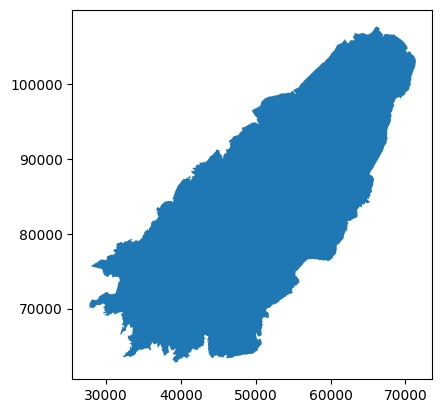

In [5]:
pnse.plot()

In [6]:
pnse.to_file("/code/data/processed/pnse/aoi/pnse.shp") 

### GEOPACKAGE

* Região Centro - área de estudo

In [7]:
gpkg = "/code/data/raw/limites/caop/Continente_CAOP2025.gpkg" 

for lyr in fiona.listlayers(gpkg):
    print(lyr)

cont_areas_administrativas
cont_distritos
cont_freguesias
cont_municipios
cont_nuts1
cont_nuts2
cont_nuts3
cont_trocos
layer_styles
inf_fonte_troco


In [8]:
lyr = "cont_nuts2"
gdf2 = gpd.read_file(gpkg, layer=lyr)

In [9]:
gdf2.crs

<Projected CRS: EPSG:3763>
Name: ETRS89 / Portugal TM06
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Portugal - mainland - onshore.
- bounds: (-9.56, 36.95, -6.19, 42.16)
Coordinate Operation:
- name: Portugual TM06
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [10]:
centro = gdf2[gdf2["nuts2"] == "Centro"]

<Axes: >

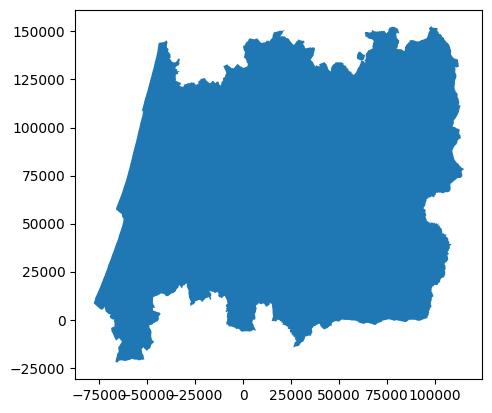

In [11]:
centro.plot()

In [12]:
centro.to_file("/code/data/processed/centro/aoi/centro.shp") 

/tmp/ipykernel_24/1416031132.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  centro.to_file("/code/data/processed/centro/aoi/centro.shp")
/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'perimetro_km' to 'perimetro_'
  ogr_write(
/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'n_municipios' to 'n_municipi'
  ogr_write(
/venv/lib/python3.12/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'n_freguesias' to 'n_freguesi'
  ogr_write(


## RASTER
* Recorte do DEM Centro à área de teste (PNSE)

In [13]:
dem = "/code/data/raw/dem_centro/dem_ctr.tif" 
lim = "/code/data/processed/pnse/aoi/pnse.shp" 
out = "/code/data/processed/pnse/topo/derived/dem_pnse.tif" 

clip_rst(
    raster=dem,
    clipshp=lim,
    outrst=out,
    nodataValue=0,
    api="gdal"
)

'/code/data/processed/pnse/topo/derived/dem_pnse.tif'

In [14]:
with rio.open(out) as src:
    print(src.shape)
    print(src.crs)
    print(src.bounds)
    print(src.res)

(4489, 4371)
EPSG:3763
BoundingBox(left=27687.781499999575, bottom=62800.9188000001, right=71397.78149999958, top=107690.9188000001)
(10.0, 10.0)
